# Entrenamiento 2 

Vamos a usar datos de Kaggle para predecir precios de casas. Los datos son de precios de casas en Ames, Iowa entre 2006 y 2010. Acá el link de Kaggle del challenge original: https://www.kaggle.com/c/house-prices-advanced-regression-techniques/data

¿Qué vamos a hacer acá?

Contruir un modelo para predecir `log(SalePrice)` usando Pytorch, vamos a comparar varias cosas para ver como se comporta. 



Primero vamos a bajar los datos directo de Kaggle


In [3]:
## Importación, semilla, dispositivo y descarga de datos 

import os
import tempfile
import urllib.request
import math
from typing import Tuple, List, Callable, Dict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
# PyTorch: tensores, módulos y herramientas de datos
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
# utilidad para mostrar tablas bonitas en notebooks
from IPython.display import display

# Semilla global para numpy/torch/random para que experimentos sean reproducibles. 
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
import random
random.seed(SEED)


# El notebook original fuerza MPS (Apple Silicon). Puedes dejarlo así si usas Mac M1/M2.
# Si quieres detección automática (GPU si está disponible, sino CPU), usa:
# DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# En este ejemplo se fijó explícitamente MPS:
DEVICE = torch.device("mps")
print("Device:", DEVICE)

# Usamos el mirror público de d2l (no requiere autenticación Kaggle).
# Ventaja: evita la necesidad de descargar el zip de Kaggle y evita problemas de permiso.
TRAIN_URL = "https://d2l-data.s3-accelerate.amazonaws.com/kaggle_house_pred_train.csv"
TEST_URL  = "https://d2l-data.s3-accelerate.amazonaws.com/kaggle_house_pred_test.csv"
TRAIN_CSV = "kaggle_house_pred_train.csv"
TEST_CSV  = "kaggle_house_pred_test.csv"

# función para leer csv
def read_csv_direct_or_temp(url: str, local_filename: str):
    """
    Intenta leer directamente con pandas.read_csv(url).
    Si la lectura directa falla (por políticas de red del entorno),
    descarga temporalmente el CSV en el directorio temporal del sistema
    y luego lo lee desde ahí.
    """
    try:
        # Lectura directa (no escribe en disco del workspace)
        df = pd.read_csv(url)
        print(f"Read {local_filename} directly from URL (no local write).")
        return df
    except Exception as e:
        print(f"Direct read failed for {local_filename}: {e}")
        tmpdir = tempfile.gettempdir()
        target = os.path.join(tmpdir, local_filename)
        try:
            print("Attempting to download to temp dir:", target)
            urllib.request.urlretrieve(url, target)
            df = pd.read_csv(target)
            print(f"Read {local_filename} from temp file:", target)
            return df
        except Exception as e2:
            raise RuntimeError(f"Failed to download/read {local_filename}: {e2}")

# ---------------- Carga de datos ----------------
# Estas variables resultantes (raw_train, raw_test) se usarán en la siguiente celda
raw_train = read_csv_direct_or_temp(TRAIN_URL, TRAIN_CSV)
raw_test  = read_csv_direct_or_temp(TEST_URL, TEST_CSV)

# Para asegurarnos que si se cargaron los datos y ver rápidamente que hay en estos datos    
print("raw_train shape:", raw_train.shape)
print("raw_test shape:", raw_test.shape)
print("Example rows (first 4):")
display(raw_train.iloc[:4, [0,1,2,3,-3,-2,-1]])


Device: mps
Read kaggle_house_pred_train.csv directly from URL (no local write).
Read kaggle_house_pred_test.csv directly from URL (no local write).
raw_train shape: (1460, 81)
raw_test shape: (1459, 80)
Example rows (first 4):


,Id,MSSubClass,MSZoning,LotFrontage,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,WD,Normal,208500
1,2,20,RL,80.0,WD,Normal,181500
2,3,60,RL,68.0,WD,Normal,223500
3,4,70,RL,60.0,WD,Abnorml,140000


##  Dataset, DataLoader y métrica en escala original

**¿Qué hace este bloque?**  
- Define `KaggleHouseDataset`, que convierte un `DataFrame` en tensores PyTorch `(X, y)` listos para entrenamiento.  
- `dataloader_from_df` crea `DataLoader` con batching y (opcional) shuffling.  
- `rmse_original_scale` convierte predicciones en `log` de regreso a dólares y calcula RMSE, que es la métrica interpretable para el negocio.

**Por qué trabajamos con `log(SalePrice)`**  
- Precio de casas muestra heteroscedasticidad (la varianza de los errores crece con el precio).  
- Transformar con `log` estabiliza la varianza y hace que MSE tenga un comportamiento más razonable. Esto es un ejemplo de **preprocesamiento** que facilita la optimización y la interpretación del error.
- Es recomendable siempre reportar métricas en *la escala que entiende el usuario final* (aquí: dólares). Por eso entrenamos en `log` pero reportamos RMSE en \$ — eso conecta el entrenamiento numérico con interpretación real.  
- También es recomendable inspeccionar distribuciones de entradas/etiquetas antes de entrenar: si `SalePrice` tiene outliers extremos, la estandarización y el log ayudan, pero debes discutir cómo esos outliers afectan el rendimiento.

**Qué revisar al ejecutar la celda**  
- `len(dataset)` y `dataset[0]` deberían devolver la forma esperada: `X` con `n_features` columnas y `y` con 1 columna (log-price).  
- Comprueba que `X.dtype == torch.float32` y `y.dtype == torch.float32`.  
- Antes de entrenar, imprime un batch de ejemplo: `next(iter(dataloader_from_df(df, batch_size=8)))` para validar shapes.



In [4]:
# Dataset, DataLoader y métrica RMSE:

class KaggleHouseDataset(Dataset):
    """
    Dataset minimalista que espera un pandas DataFrame con columna 'SalePrice'.

    - X: todas las columnas excepto 'SalePrice' (convertidas a float32)
    - y: la columna 'SalePrice' convertida a float32 y, opcionalmente, transformada con log()
    Razonamiento: predecimos log(SalePrice) porque reduce heteroscedasticidad (varianza creciente con precio).
    """
    def __init__(self, df: pd.DataFrame, label='SalePrice', log_label=True):
        # Validación simple: asegurar que la etiqueta existe
        if label not in df.columns:
            raise RuntimeError(f"DataFrame debe contener la columna '{label}'")
        # Extraemos features y labels
        X = df.drop(columns=[label]).values.astype(np.float32)   # matriz de diseño
        y = df[label].values.astype(np.float32).reshape(-1, 1)   # columna etiqueta
        # Aplicamos la transformación log si corresponde
        if log_label:
            y = np.log(y)
        # Convertimos a tensores PyTorch (float32)
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)

    def __len__(self): 
         # número de ejemplos
        return self.X.shape[0]
    def __getitem__(self, idx):
        # devuelve un par (X[idx], y[idx]) — listo para DataLoader 
        return self.X[idx], self.y[idx]

def dataloader_from_df(df, batch_size=64, shuffle=True):
    """
    Construye un DataLoader PyTorch a partir del DataFrame preprocesado.
    - shuffle=True para entrenamiento (mezcla minibatches)
    - shuffle=False para validación/test
    """
    ds = KaggleHouseDataset(df, log_label=True)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

def rmse_original_scale(pred_log: torch.Tensor, y_true: torch.Tensor) -> float:
    """
    Convierte predicciones en log-espacio a la escala original mediante exp()
    y calcula RMSE (root mean squared error) en dólares.
    - pred_log: tensor con predicciones de log(precio) shape [n,1]
    - y_true: tensor con precio real en dólares shape [n,1]
    """
    # exp para volver a la escala de precios
    yhat = torch.exp(pred_log)
    return torch.sqrt(((yhat - y_true)**2).mean()).item()

### Modelo e inicialización

**Qué hace este bloque:**
- Define un modelo lineal sencillo `LinearModel` con una sola capa `nn.Linear`.
- Proporciona tres estrategias de inicialización de pesos:
  1. **Normal pequeña** (pesos ≈ 0 ± 0.01) — inicialización conservadora.
  2. **Xavier/Glorot** — mantiene mejor la varianza de las activaciones entre capas.
  3. **Kaiming/He** — diseñada para redes con ReLU; incluida aquí para comparar comportamientos.

**Intución:**
- La **inicialización** es importante: fija la escala inicial de los parámetros y condiciona la dinámica del descenso de gradiente.  
- Si los pesos iniciales son demasiado grandes + learning rate grande → **gradientes explosivos**; si son demasiado pequeños → **aprendizaje lento**. Xavier y Kaiming nacen de análisis sobre cómo propagan la varianza a través de capas.
- En nuestro caso (modelo lineal), las diferencias entre inicializadores son más sutiles que en redes profundas. 
- Pero es útil saber como definir e utilizar distintas inicializaciones 

**Qué observar al ejecutar:**
- Rápidamente después de inicializar, imprime `std` de los pesos: `torch.cat([p.view(-1) for p in model.parameters()]).std()` para ver la escala.
- Observa la velocidad de descenso de la pérdida en experimentos con cada inicialización.
- Ten en cuenta que Kaiming fue diseñada para ReLU; para redes lineales o con activaciones simétricas Xavier suele ser más apropiada.




In [5]:
# ---------------- Modelo e inicialización ----------------
# Vamos a definir un modelo lineal simple usando nn.Linear de PyTorch
# y tres estrategias de inicialización para comparar su efecto en el entrenamiento.

class LinearModel(nn.Module):
    def __init__(self, n_features: int):
        super().__init__()
        # Capa lineal: entrada = n_features, salida = 1 (predicción de log-price)
        # bias=True añade un término independiente (offset)
        self.linear = nn.Linear(n_features, 1, bias=True)
    def forward(self, x): 
        # forward: aplicación directa de la capa lineal
        return self.linear(x)

# ---------------- Inicializadores ----------------
# Cada función comprueba si el módulo es nn.Linear y aplica la
# inicialización sólo a los parámetros de esa capa.

def init_weights_normal(m: nn.Module, std: float = 0.01):
    # Inicialización normal (Gaussian) con media 0 y desviación std pequeña.
    # Esta inicialización hace que los pesos sean muy pequeños al inicio.
    if isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, 0.0, std)
        if m.bias is not None:
            nn.init.zeros_(m.bias) # bias = 0 por simplicidad

def init_weights_xavier(m: nn.Module):
    # Inicialización Xavier/Glorot (útil para señales que atraviesan capas lineales o simétricas)
    # Diseñada para mantener la varianza de las activaciones estable a través de capas
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)

def init_weights_kaiming(m: nn.Module):
    # Inicialización Kaiming/He — originalmente pensada para redes con ReLU.
    # La usamos aquí por comparación: en una red lineal pura puede no ser "óptima",
    # pero es instructivo ver el efecto en la dinámica de optimización.
    if isinstance(m, nn.Linear):
        nn.init.kaiming_uniform_(m.weight, nonlinearity='linear')
        if m.bias is not None:
            nn.init.zeros_(m.bias)

### Entrenamiento con diagnósticos

**Resumen:**
- Entrena un `model` con `train_loader` y evalúa en `val_loader`.
- Guarda métricas útiles por época: `train_loss`, `val_loss`, `grad_norms`, `weight_stds` y `param_snapshots`.
- Usa `SGD` sin regularización para aislar el efecto de `initialization` y `lr` (tal como nos pediste).

**¿Por qué guardamos estas métricas?**  
- **train_loss / val_loss:** evidencia directa de ajuste; comparar train vs val muestra posible sobreajuste (aun sin regularización).  
- **grad_norms:** normas muy grandes indican riesgo de inestabilidad; normas muy pequeñas sugieren aprendizaje lento.  
- **weight_stds:** la desviación estándar de los parámetros muestra la escala de los pesos; cambios abruptos indican actualizaciones grandes (posible lr grande).  
- **param_snapshots y histogramas:** permiten visualizar cómo se distribuyen los pesos a lo largo del entrenamiento (asimetría, colas largas, etc.). 

**Qué interpretaciones se pueden sacar al ejecutar:**
1. Si la **pérdida de validación** decrece de manera suave y se estabiliza, la configuración (init+lr) es razonable.  
2. Si la **train_loss** cae pero la **val_loss** sube → posible sobreajuste (aunque estamos con un modelo lineal, también puede indicar ruido).  
3. Si `grad_norms` presenta picos esporádicos → revisar learning rate y outliers en datos.  
4. Si `weight_stds` crece rápidamente → learning rate muy alto o escala de gradientes inadecuada.

**Nota práctica:**  
- Si usas GPU/MPS verifica memoria (OOM). En caso de OOM reduce `batch_size` o usa `device='cpu'` para depuración.


In [6]:
# ---------------- Entrenamiento con diagnósticos ----------------
# Esta función entrena el modelo y recoge métricas útiles para diagnóstico:
# - pérdidas (train/val) por época
# - norma de los gradientes por época
# - desviación estándar de los pesos por época
# - snapshots (vectores de parámetros) para histogramas posteriores

from copy import deepcopy

def train_with_diagnostics(model: nn.Module,
                           train_loader: DataLoader,
                           val_loader: DataLoader,
                           lr: float = 0.01,
                           epochs: int = 10,
                           device = DEVICE,
                           save_param_snapshots: bool = True):
    # Mover el modelo al dispositivo elegido (mps/cuda/cpu)                       
    model = model.to(device)
    # Optimizer: SGD simple (sin momentum ni regularización)
    opt = torch.optim.SGD(model.parameters(), lr=lr)
    # Loss: MSE sobre log(SalePrice)
    criterion = nn.MSELoss() 
     
    # Contenedor para almacenar métricas a lo largo del entrenamiento 
    history = {
        'train_loss': [],     # pérdida media de entrenamiento por epoch
        'val_loss': [],       # pérdida media de validación por epoch
        'grad_norms': [],     # norma (L2) máxima de gradientes observada en la epoch
        'weight_stds': [],    # desviación estándar de todos los pesos (indicador de escala)
        'param_snapshots': [] # snapshots de parámetros (vector plano) para histogramas
    }
    
    # Bucle principal de entrenamiento por épocas
    for epoch in range(epochs):
        model.train()  # modo training (activa dropout/batchnorm si existieran)
        total_loss = 0.0
        total_samples = 0
        grad_norm_this_epoch = 0.0 # guardamos la norma máxima de grads en la epoch
        
        # ITERAR sobre minibatches de entrenamiento
        for X, y in train_loader:
            # Mover batch al dispositivo
            X, y = X.to(device), y.to(device)
            # Forward
            pred = model(X)
            # Loss
            loss = criterion(pred, y)
            # Backprop
            opt.zero_grad()
            loss.backward()
            # -- Diagnóstico: norma L2 de los gradientes agregada sobre parámetros
            total_sq = 0.0
            for p in model.parameters():
                if p.grad is not None:
                    # p.grad.norm(2) es la norma L2 del gradiente de ese tensor
                    total_sq += float(p.grad.detach().norm(2).item())**2
            grad_norm = math.sqrt(total_sq)
            # Elegimos guardar la norma máxima observada en la epoch (útil para detectar picos)
            grad_norm_this_epoch = max(grad_norm_this_epoch, grad_norm) 
            # Actualización de parámetros
            opt.step()
            # Acumulamos pérdida para cálculo de media ponderada por batch_size
            batch_size = X.shape[0]
            total_loss += loss.item()*batch_size
            total_samples += batch_size
        
        # Media de la pérdida de entrenamiento en la epoch
        train_loss = total_loss / total_samples
        

        # ---------------- Validación (sin gradientes) ----------------
        model.eval()
        val_total = 0.0
        val_samples = 0
        with torch.no_grad():
            for Xv, yv in val_loader:
                Xv, yv = Xv.to(device), yv.to(device)
                pv = model(Xv)
                # sumamos MSE por ejemplo (reduction='sum') para luego promediar por número de ejemplos
                val_total += nn.functional.mse_loss(pv, yv, reduction='sum').item()
                val_samples += Xv.shape[0]
        val_loss = val_total / val_samples
        

        # ---------------- Estadística de parámetros ----------------
        # Concatenamos todos los parámetros en un vector para calcular std
        all_params = torch.cat([p.data.view(-1) for p in model.parameters()]).cpu().clone()
        w_std = float(all_params.std().item())
        
        # Guardar métricas en history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['grad_norms'].append(grad_norm_this_epoch)
        history['weight_stds'].append(w_std)
        if save_param_snapshots:
            history['param_snapshots'].append(all_params.numpy().copy())
        
        # Impresión periódica para monitorizar (cada ~epochs/5)
        if (epoch + 1) % max(1, epochs // 5) == 0 or epoch == 0:
            print(f"Epoch {epoch+1}/{epochs} — train log-MSE: {train_loss:.6f}, val log-MSE: {val_loss:.6f}, grad-norm (max this epoch): {grad_norm_this_epoch:.6g}, weight-std: {w_std:.6g}")

    # Devolver historial y modelo final
    return history, model

### Gradientes: comprobación numérica (diferencias finitas) y comparación con Autograd

**¿Qué hacemos aquí?**  
- Implementamos `finite_difference_gradients` que calcula la aproximación por diferencias finitas (central) del gradiente elemento a elemento.  
- Implementamos `compare_autograd_fd` que compara el gradiente computado por `autograd` (loss.backward()) frente a la aproximación numérica.

**Notas prácticas / advertencias:**  
- **Coste:** la aproximación por diferencias finitas es *muy* costosa: si un tensor de parámetros tiene `N` elementos, requiere `2N` evaluaciones de la función de pérdida. Por eso **usar solo** en modelos pequeños o con un *subconjunto* muy pequeño de parámetros.  
- **Elección de `eps`:** para `float32` suele usarse `eps` entre `1e-6` y `1e-4`. Si `eps` es demasiado pequeño la resta pierde precisión por rounding; si es demasiado grande la aproximación es tosca.  
- **Restauración de parámetros:** la función restaura los parámetros al valor central original para no contaminar el estado del modelo.

**¿Por qué estamos haciendo esto?:**  
- Para verificar la implementación de autograd, sabemos que funciona pero es buena idea cuando aprendemos algo nuevo asegurarnos 
- Interpretar los errores relativos (`rel_err`). Si `rel_err` ≪ 1e-3 el gradiente es coherente; errores grandes indican bug o problemas numéricos.


In [7]:
# ---------------- Gradientes: finite-difference + comparación con autograd ----------------


def finite_difference_gradients(model: nn.Module, X: torch.Tensor, y: torch.Tensor, eps: float = 1e-5):
    """
    Calcula aproximación por diferencias finitas de los gradientes para cada parámetro del modelo.
    - model: modelo en evaluación (se hará forward con model(X))
    - X, y: tensores pequeños (usar batch pequeño, p.ej. 5-10 ejemplos) en el mismo device que model
    - eps: paso para la diferencia central (ajustar entre 1e-6 y 1e-3 según precisión y dtype)
    Devuelve: lista de arrays numpy con la aproximación del gradiente para cada parámetro (misma forma que cada p)
    """
    model.eval() # poner el modelo en modo evaluación 
    # Guardar parámetros centrales para restaurarlos al final
    central_params = [p.detach().cpu().numpy().copy() for p in model.parameters()]
    approx_grads = []
    # Usamos torch.no_grad() porque vamos a modificar parámetros manualmente
    with torch.no_grad():
        # Iterar por cada tensor de parámetros del modelo
        for p_idx, p in enumerate(model.parameters()):
            p_shape = p.shape
            p_flat_size = p.numel()
            # vector plano para almacenar aproximaciones
            g_approx = np.zeros(p_flat_size, dtype=float)
            # iterar elemento por elemento (costoso si el tensor es grande)
            for i in range(p_flat_size):
                 # leer valor original
                orig = float(p.view(-1)[i].item())
                # perturbación +eps
                p.view(-1)[i] = orig + eps
                # computar pérdida (nota: model(X) usa los parámetros perturbados)
                l_plus = float(nn.functional.mse_loss(model(X), y).item())
                # perturbación -eps
                p.view(-1)[i] = orig - eps
                l_minus = float(nn.functional.mse_loss(model(X), y).item())\
                # restaurar valor original
                p.view(-1)[i] = orig
                # diferencia central: (f(x+eps) - f(x-eps)) / (2*eps)
                g_approx[i] = (l_plus - l_minus) / (2 * eps)
            # dar a la aproximación la forma original del tensor
            approx_grads.append(g_approx.reshape(p_shape))
   
    # Restaurar parámetros originales (por seguridad)
    for p, cp in zip(model.parameters(), central_params):
        with torch.no_grad():
            p.copy_(torch.from_numpy(cp).to(p.device))
    return approx_grads


def compare_autograd_fd(model: nn.Module, X: torch.Tensor, y: torch.Tensor, eps=1e-5):
    """
    Compara los gradientes calculados por autograd (loss.backward()) contra la aproximación
    por diferencias finitas (finite_difference_gradients).
    - Devuelve lista de diccionarios por parámetro con:
        'rel_err'       : error relativo máximo entre autograd y finite-diff
        'max_abs_diff'  : máxima diferencia absoluta
        'autograd_norm' : max abs valor en el gradiente autograd
        'fd_norm'       : max abs valor en el gradiente aproximado
    Importante: usar en modelos pequeños / batches pequeños por coste.
    """
    # Asegurar estado limpio de gradientes
    model.zero_grad()
    # calcular gradientes por autograd
    pred = model(X)
    loss = nn.functional.mse_loss(pred, y)
    loss.backward()

    # guardar gradientes de autograd como numpy
    autograd_grads = [p.grad.detach().cpu().numpy().copy() if p.grad is not None else None for p in model.parameters()]

    # calcular gradientes aproximados por diferencias finitas
    approx = finite_difference_gradients(model, X, y, eps=eps)

    results = []
    for g_auto, g_approx in zip(autograd_grads, approx):
        # asegurar arrays numpy
        g_auto = np.array(g_auto)
        g_approx = np.array(g_approx)
 
        # diferencias absolutas y relativo (evitar div por cero) 
        abs_diff = np.abs(g_auto - g_approx)
        max_abs = float(abs_diff.max())
        denom_scalar = float(max(np.abs(g_auto).max(), np.abs(g_approx).max(), 1e-12))
        rel_err = float((abs_diff / denom_scalar).max())

        results.append({
            'rel_err': rel_err,
            'max_abs_diff': max_abs,
            'autograd_norm': float(np.abs(g_auto).max()),
            'fd_norm': float(np.abs(g_approx).max())
        })
    return results


### Solución cerrada (ecuación normal) para regresión lineal

**¿Qué hace este bloque?**  
- Calcula la solución analítica `w = (X^T X)^{-1} X^T y` para la regresión lineal sobre `log(SalePrice)`.  
- Utiliza `pinv` (pseudo-inversa) por robustez numérica (evita problemas si `X^T X` es singular o mal condicionada).

**Ventajas / limitaciones:**  
- **Ventaja:** devuelve la solución exacta (en espacio de parámetros lineales) en un solo paso; no requiere optimización iterativa.  
- **Limitación:** la matriz `(X^T X)` tiene tamaño `d x d` (d = #features). Si `d` es grande (decenas de miles) la inversión se vuelve costosa tanto en memoria como en tiempo (O(d^3) para inversa). Además, problemas de condicionalidad numérica pueden surgir si hay colinealidad o features mal escaladas.  
- **Interpretación práctica :** Las soluciones analíticas son excelentes para entender propiedades teóricas y para comparar — p. ej. te permiten verificar que SGD converge a una solución cercana cuando el modelo es puramente lineal y la optimización bien comportada.

**Qué comparar en los experimentos:**  
- Comparar `val_loss` y RMSE (en escala original) entre la solución cerrada y la obtenida por SGD.  
- Analizar tiempo de cómputo y consumo de memoria. En datasets pequeños la solución cerrada suele ser más rápida y precisa; en datasets grandes o con muchas features, SGD (o métodos iterativos) es preferible.


In [8]:
# ---------------- Solución cerrada para regresión lineal ----------------
def closed_form_solution(df: pd.DataFrame):
    """
    Calcula la solución analítica (ecuación normal) para la regresión lineal sobre
    target = log(SalePrice).
    - df: DataFrame que contiene features y la columna 'SalePrice'
    - Devuelve w (incluye bias) como numpy array shape [n_features + 1, 1]
    """
    # X: matriz de diseño (sin bias) en float64 para mayor estabilidad numérica
    X = df.drop(columns=['SalePrice']).values.astype(np.float64)
    # y: etiqueta transformada (log)
    y = np.log(df['SalePrice'].values.astype(np.float64)).reshape(-1,1)
    # Xb: añadimos columna de 1s para el bias
    Xb = np.hstack([np.ones((X.shape[0],1)), X])
    # w = (X^T X)^{-1} X^T y; usamos pseudo-inversa para mayor estabilidad numérica
    w = np.linalg.pinv(Xb.T @ Xb) @ Xb.T @ y
    return w

def closed_form_predict(w: np.ndarray, X: np.ndarray):
    """
    Predice log-prices usando el vector w (incluye bias).
    - X: matriz de features (sin columna de 1s)
    - devuelve predicciones en log-scale (shape [n,1])
    """
    Xb = np.hstack([np.ones((X.shape[0],1)), X])
    return Xb @ w  
   

### Preprocesamiento y Experimentos de inicialización

**Preprocesamiento (qué y por qué):**
- Combinamos `train` y `test` (solo las features) antes de one-hot encoding para garantizar que **ambos conjuntos** tengan exactamente las mismas columnas de entrada. Esto evita columnas faltantes/extra en la inferencia.  
- Estandarizamos columnas numéricas usando la media y desviación estándar del conjunto combinado para mantener consistencia entre train y test.  
- Rellenamos NaNs numéricos con 0 tras la estandarización (una decisión práctica; discutir alternativas: imputación, mediana, flags).

**Experimentos (¿qué comparamos?):**
- Tres inicializaciones: `normal (std=0.01)`, `xavier`, `kaiming`.  
- Condiciones controladas: mismo split train/val, mismo `lr`, mismas `epochs` y `batch_size`.  
- Guardar `history` (train/val loss, grad norms, weight stds) para cada inicialización y comparar gráficamente.

**Interpretación (qué buscar y por qué):**
- **Curvas de pérdida:** comparamos rapidez de convergencia y estabilidad. De acuerdo con la teoría una inicialización que preserve la varianza (Xavier) tiende a estabilizar la propagación de la señal y los gradientes.  
- **Grad-norms:** picos o tendencias crecientes sugieren inestabilidad. Comparar grad-norm entre inicializaciones muestra si alguna favorece gradientes más suaves.  
- **Weight-std:** evolución de la escala de los pesos — un crecimiento rápido sugiere actualizaciones grandes (posible lr demasiado grande).  
- **Closed-form vs SGD:** para este problema lineal la solución cerrada sirve como referencia "óptima" (dentro del modelo lineal) — si SGD se aproxima a esa solución, es señal de que la optimización funciona correctamente.


In [9]:
# Experimentos 

## Arreglamos los datos para poder correr los experimentos 
def preprocess(raw_train: pd.DataFrame, raw_test: pd.DataFrame, label='SalePrice'):
    # Número de filas del train original (para luego re-extraer el split)
    n_train = raw_train.shape[0]
    # Separar columnas de features (sin Id y sin label para train)
    feats_train = raw_train.drop(columns=['Id', label])
    feats_test  = raw_test.drop(columns=['Id'])
    # Concatenar (train luego test) para que one-hot genere las mismas columnas
    all_feats = pd.concat([feats_train, feats_test], ignore_index=True)
 
    # Identificar columnas numéricas (excluye object / cadenas)
    numeric_cols = all_feats.select_dtypes(exclude='object').columns
    # Estandarizar: (x - mean) / std usando estadísticas del conjunto combinado
    all_feats[numeric_cols] = all_feats[numeric_cols].apply(lambda c: (c - c.mean()) / (c.std()))
    # Reemplazar NaNs numéricos por 0 (pasa si std==0 o columnas vacías)
    all_feats[numeric_cols] = all_feats[numeric_cols].fillna(0.0)
    # One-hot encode de las categóricas; dummy_na=True crea columna para NA
    all_feats = pd.get_dummies(all_feats, dummy_na=True)

    # Separar de nuevo en train / test según el conteo original
    processed_train = all_feats.iloc[:n_train].copy()
    processed_train[label] = raw_train[label].values # reinsertar la etiqueta
    processed_test = all_feats.iloc[n_train:].copy()

    return processed_train.reset_index(drop=True), processed_test.reset_index(drop=True)

# Si proc_train/proc_test no existen o están corruptos, recomputar    
need_recompute = False
if 'proc_train' not in globals() or 'proc_test' not in globals():
    need_recompute = True
else:
    if 'SalePrice' not in proc_train.columns:
        need_recompute = True

if need_recompute:
    print("Computing proc_train / proc_test via preprocess(...)")
    proc_train, proc_test = preprocess(raw_train, raw_test)
    print("proc_train shape:", proc_train.shape, "proc_test shape:", proc_test.shape)
else:
    print("proc_train/proc_test already defined. proc_train shape:", proc_train.shape)

# comprobación simple
if 'SalePrice' not in proc_train.columns:
    raise RuntimeError("proc_train does not contain 'SalePrice' after preprocessing. Aborting.")



# ---------------- Experimentos de inicialización ----------------
# Split reproducible en train/val
train_df_full, val_df_full = train_test_split(proc_train, test_size=0.2, random_state=SEED)
print("Train / Val:", train_df_full.shape, val_df_full.shape)

# Función que lanza un experimento con una inicialización dada
def run_init_experiment(init_fn: Callable, name: str,
                        lr=0.01, epochs=20, batch_size=64):
    # número de features = columnas menos la etiqueta
    n_features = proc_train.shape[1] - 1
    # construir modelo e inicializar
    model = LinearModel(n_features)
    model.apply(init_fn)
    # data loaders
    train_loader = dataloader_from_df(train_df_full, batch_size=batch_size, shuffle=True)
    val_loader = dataloader_from_df(val_df_full, batch_size=batch_size, shuffle=False)
    # entrenar y devolver historial + modelo
    history, model_trained = train_with_diagnostics(model, train_loader, val_loader, lr=lr, epochs=epochs, device=DEVICE)
    return history, model_trained

# Lista de inicializadores a probar
results = {}
inits = [
    (lambda m: init_weights_normal(m, std=0.01), "normal_std_0.01"),
    (init_weights_xavier, "xavier"),
    (init_weights_kaiming, "kaiming")
]
# Ejecutar experiments (imprime progreso)
for init_fn, name in inits:
    print("\n--- Running init:", name)
    hist, mdl = run_init_experiment(init_fn, name, lr=0.01, epochs=20, batch_size=64)
    results[name] = (hist, mdl)


Computing proc_train / proc_test via preprocess(...)
proc_train shape: (1460, 331) proc_test shape: (1459, 330)
Train / Val: (1168, 331) (292, 331)

--- Running init: normal_std_0.01
Epoch 1/20 — train log-MSE: 10.279185, val log-MSE: 0.442280, grad-norm (max this epoch): 132.866, weight-std: 0.107713
Epoch 4/20 — train log-MSE: 0.297148, val log-MSE: 0.240354, grad-norm (max this epoch): 1.85525, weight-std: 0.107512
Epoch 8/20 — train log-MSE: 0.187570, val log-MSE: 0.163364, grad-norm (max this epoch): 2.29757, weight-std: 0.1091
Epoch 12/20 — train log-MSE: 0.137679, val log-MSE: 0.126056, grad-norm (max this epoch): 4.22433, weight-std: 0.110019
Epoch 16/20 — train log-MSE: 0.111795, val log-MSE: 0.104735, grad-norm (max this epoch): 1.93442, weight-std: 0.111154
Epoch 20/20 — train log-MSE: 0.092681, val log-MSE: 0.092490, grad-norm (max this epoch): 1.44783, weight-std: 0.112063

--- Running init: xavier
Epoch 1/20 — train log-MSE: 10.055245, val log-MSE: 0.564963, grad-norm (ma

## Interpretación detallada de las gráficas

A continuación describimos cómo leer cada panel y qué nos dicen los resultados que estamos viendo. 

### 1. Curvas de pérdida (arriba izquierda — *Log-MSE Loss curves*)
- **Qué muestra:** para cada inicializador se dibuja la pérdida en escala logarítmica (`log-MSE`) tanto en *train* como en *val* a lo largo de las épocas.
- **Qué observar aquí:** 
  - Un **descenso rápido** de la pérdida en las primeras épocas indica que el optimizador está encontrando direcciones útiles; una caída muy abrupta seguida por oscilaciones puede indicar pasos demasiado grandes.
  - Si *train* cae pero *val* se estabiliza o sube, hay signo de sobreajuste o diferencia en ruido entre los conjuntos.
- **En la gráfica:** se ve una caída enorme en la *época 0 → 1* (el modelo pasa de predicciones iniciales totalmente aleatorias a un ajuste inicial muy mejorado), y luego una convergencia lenta hacia valores bajos (~0.1 en log-MSE). Esto es típico cuando la pérdida inicial (modelo sin entrenar) es grande y el optimizador corrige rápidamente.
- **Conclusión práctica:** todos los inicializadores convergen a pérdidas bajas, pero la **magnitud y la rapidez** con que lo hacen varían ligeramente. La inicialización *normal (std=0.01)* parece dar la menor val-log-MSE.

---

### 2. Norma de gradientes (arriba derecha — *Gradient norms (max per epoch)*)
- **Qué muestra:** la norma L2 acá guardamos la máxima observada en la epoch de los gradientes agregada sobre todos los parámetros.
- **Por qué es útil:** la norma de los gradientes indica la magnitud de las actualizaciones (siempre multiplicada por el learning rate). Normas muy grandes en una epoch pueden preceder inestabilidad o divergencia; normas muy pequeñas pueden implicar aprendizaje lento.
- **En la gráfica:** hay un **pico muy grande en la época 0**, luego la norma cae a valores pequeños y se mantiene oscilante. El pico inicial coincide con la gran caída de pérdida (el gradiente grande era necesario para corregir el modelo que estaba muy lejos).
- **Interpretación :** La escala inicial de los pesos y la escala de las entradas determinan la escala de los gradientes. Un init que produce mayores pesos iniciales tenderá a generar gradientes más grandes (si las entradas y etiquetas no están bien normalizadas). Observa si algún inicializador produce picos persistentes: eso podría indicar riesgo (aumenta la probabilidad de pasos inestables para lrs mayores).
- **Acción:** si ves picos recurrentes, prueba reducir el `lr` o inicializar con una `std` menor.

---

### 3. Desviación estándar de pesos (abajo izquierda — *Weight std across epochs*)
- **Qué muestra:** desviación estándar (std) de todos los parámetros concatenados por época. Indica la *escala* de los pesos.
- **Por qué importa:** el tamaño típico de los pesos afecta la amplificación/atenuación de señales y gradientes. Cambios rápidos en `weight_std` señalan actualizaciones grandes.
- **En tus resultados:** 
  - Los tres inicializadores comienzan con `weight_std` distinto (Xavier ligeramente mayor que Kaiming y normal más pequeña).
  - Durante el entrenamiento las `weight_std` evolucionan suavemente: Xavier mantiene la std más alta, normal empieza baja y sube un poco.
- **Interpretación:** Xavier genera pesos de mayor magnitud inicial que, bajo SGD con este `lr`, permanecen relativamente más grandes. La inicialización *normal* con std pequeña produce parámetros más pequeños, lo que puede explicar por qué es más estable en este experimento (menos riesgo de grandes actualizaciones).
- **Nota:** examina si `weight_std` crece sin control durante el entrenamiento; en ese caso un ajuste de `lr` o una regularización (L2) sería recomendable.

---

### 4) Pérdida final de validación por inicializador (abajo derecha — *Final val log-MSE per init*)
- **Qué muestra:** barra con la última (final) `val_loss` (log-MSE) para cada inicializador.
- **Interpretación práctica de tus resultados:** 
  - *normal_std_0.01* parece obtener la mejor pérdida final (la más baja).
  - *xavier* muestra la peor pérdida final entre los tres, con *kaiming* en medio.
- **Posible explicación:** en un modelo **lineal** con features ya estandarizadas, una inicialización muy conservadora (normal con std pequeña) puede facilitar un descenso más estable y producir mejor generalización en este problema concreto. Xavier y Kaiming fueron diseñadas pensando en redes profundas con activaciones no lineales; sus beneficios no siempre se traducen directamente a modelos lineales.
- **Recomendación:** la “mejor” inicialización depende del **modelo** y del **optim**. Para redes profundas con ReLU Kaiming suele ser buena; para capas lineales o activaciones simétricas Xavier suele ser preferible. En regresión lineal simple, una inicialización muy pequeña o la solución cerrada pueden funcionar mejor.


normal_std_0.01      final val-logMSE: 0.092490 | final weight-std: 0.112063 | max grad-norm: 132.866
xavier               final val-logMSE: 0.129844 | final weight-std: 0.127121 | max grad-norm: 127.923
kaiming              final val-logMSE: 0.100272 | final weight-std: 0.121138 | max grad-norm: 131.471


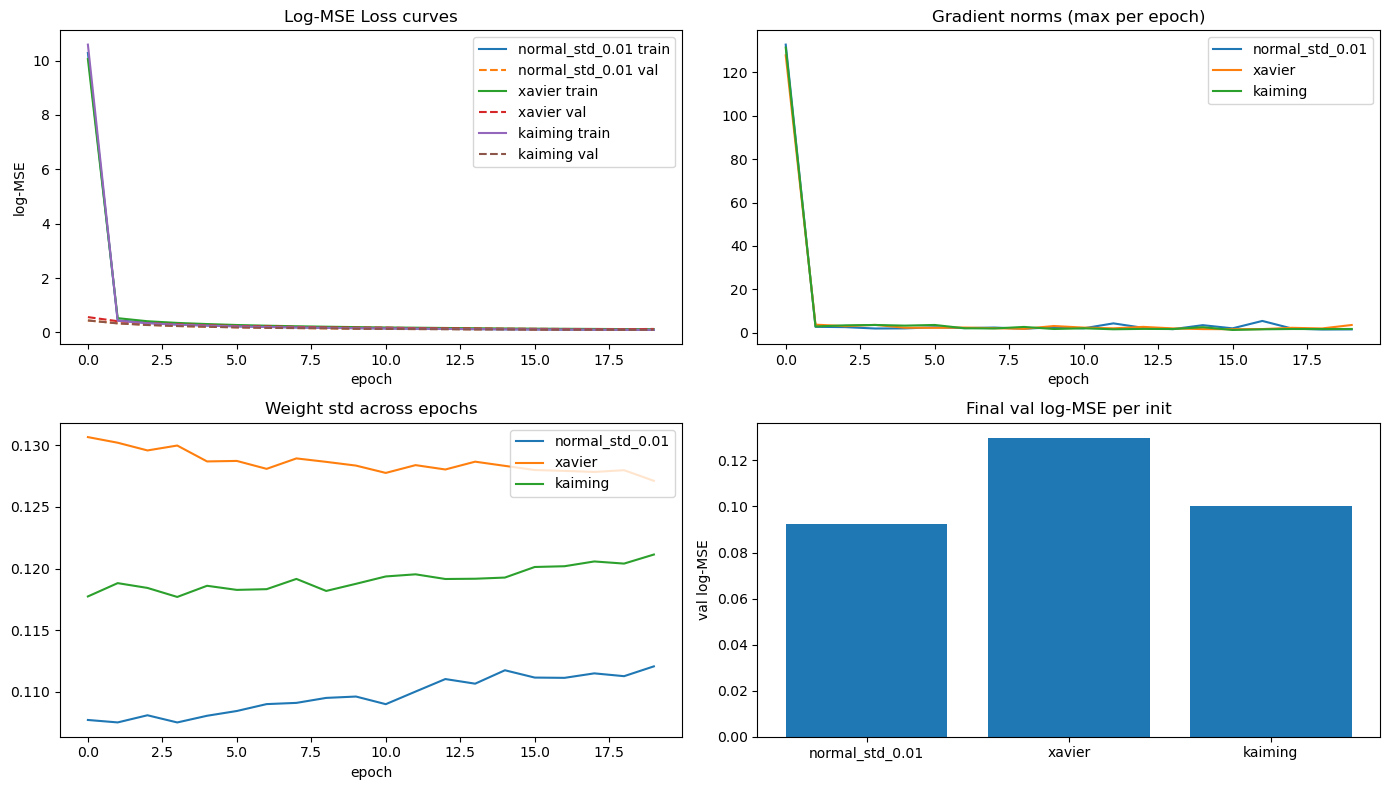

In [10]:
# Graficas de desempeño
plt.figure(figsize=(14,8))
# Pérdada
plt.subplot(2,2,1)
for name,(hist,_) in results.items():
    plt.plot(hist['train_loss'], label=f'{name} train')
    plt.plot(hist['val_loss'], '--', label=f'{name} val')
plt.title('Log-MSE Loss curves'); plt.xlabel('epoch'); plt.ylabel('log-MSE'); plt.legend()

# Norma de los gradientes
plt.subplot(2,2,2)
for name,(hist,_) in results.items():
    plt.plot(hist['grad_norms'], label=name)
plt.title('Gradient norms (max per epoch)'); plt.xlabel('epoch'); plt.legend()

# Weight std
plt.subplot(2,2,3)
for name,(hist,_) in results.items():
    plt.plot(hist['weight_stds'], label=name)
plt.title('Weight std across epochs'); plt.xlabel('epoch'); plt.legend()

# Final validation losses (bar)
plt.subplot(2,2,4)
names = list(results.keys())
final_vals = [results[n][0]['val_loss'][-1] for n in names]
plt.bar(names, final_vals); plt.title('Final val log-MSE per init'); plt.ylabel('val log-MSE')
plt.tight_layout()


# Resumen numérico final por inicializador
for name, (hist, mdl) in results.items():
    if hist is None:
        print(name, "-> no disponible")
        continue
    final_val = hist['val_loss'][-1]
    final_weight_std = hist['weight_stds'][-1]
    max_grad = max(hist['grad_norms']) if hist['grad_norms'] else float('nan')
    print(f"{name:<20} final val-logMSE: {final_val:.6f} | final weight-std: {final_weight_std:.6f} | max grad-norm: {max_grad:.6g}")

### Cambiando la tasa de aprendizaje (LR sweep)

**Qué hacemos:** 
- robamos cuatro valores de `lr` (0.001, 0.01, 0.1, 0.5) manteniendo todo lo demás fijo (misma inicialización Xavier, mismas épocas y batch).  
- La curva mostrada es la *validación* de log-MSE por época, en escala log para visualizar explosiones.

**Cómo leer la figura:**  
- Curvas que descienden suavemente → aprendizaje estable.  
- Curvas que suben abruptamente o alcanzan valores enormes (en la escala log) → *divergencia* o saturación numérica (loss explota).  
- Comparar velocidades: lr pequeño = aprendizaje lento; lr demasiado grande = inestabilidad.

**Interpretación de la gráfica:**  
- En la figura se observan `lr=0.001` y `lr=0.01` estables y con pérdida decreciente; `lr=0.1` puede mostrar mayor pérdida (más ruido), y `lr=0.5` aparentemente provoca explosión (valores astronómicos en la escala log), señal clara de inestabilidad.  
- Conclusión: existe un rango de `lr` "seguro" para este problema (probablemente alrededor de 1e-3 — 1e-2). `lr=0.5` es demasiado grande y provoca actualizaciones que desbordan la región de baja curvatura.




=== LR 0.001 ===
Epoch 1/20 — train log-MSE: 61.526323, val log-MSE: 15.434303, grad-norm (max this epoch): 129.52, weight-std: 0.10664
Epoch 4/20 — train log-MSE: 0.952091, val log-MSE: 0.758510, grad-norm (max this epoch): 8.01598, weight-std: 0.130908
Epoch 8/20 — train log-MSE: 0.695616, val log-MSE: 0.623199, grad-norm (max this epoch): 6.21907, weight-std: 0.131067
Epoch 12/20 — train log-MSE: 0.596845, val log-MSE: 0.540382, grad-norm (max this epoch): 3.59162, weight-std: 0.13012
Epoch 16/20 — train log-MSE: 0.527254, val log-MSE: 0.476792, grad-norm (max this epoch): 2.53398, weight-std: 0.129688
Epoch 20/20 — train log-MSE: 0.472552, val log-MSE: 0.423716, grad-norm (max this epoch): 2.50909, weight-std: 0.129201

=== LR 0.01 ===
Epoch 1/20 — train log-MSE: 10.066122, val log-MSE: 0.555726, grad-norm (max this epoch): 131.601, weight-std: 0.135158
Epoch 4/20 — train log-MSE: 0.360885, val log-MSE: 0.362259, grad-norm (max this epoch): 4.87713, weight-std: 0.131401
Epoch 8/20

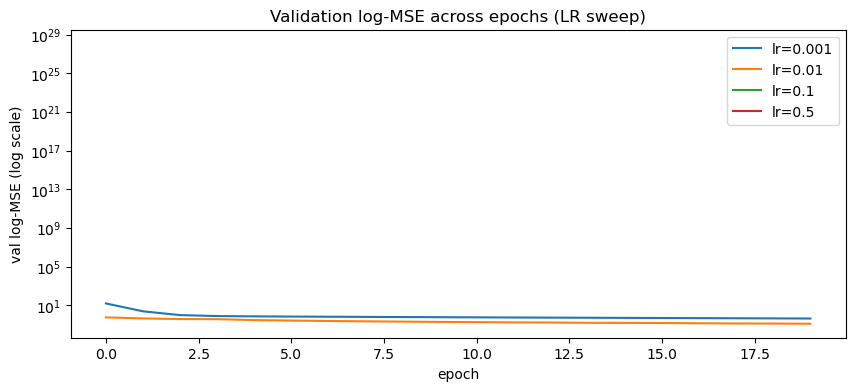

In [11]:
# ---------------- Tasa de aprendizaje (LR sweep) ----------------
# Probamos varios learning-rates para ver su efecto en la estabilidad y convergencia.
lrs = [1e-3, 1e-2, 1e-1, 0.5]
lr_results = {}
for lr in lrs:
    print(f"\n=== LR {lr} ===")
    # Usamos Xavier como inicialización neutral para esta comparación
    # run_init_experiment entrena y devuelve (history, modelo)
    hist, mdl = run_init_experiment(init_weights_xavier, f"xavier_lr{lr}", lr=lr, epochs=20, batch_size=64)
    lr_results[lr] = (hist, mdl)

# Plot de las curvas de validación (escala log para ver divergencias)
# Plot de las curvas de validación (escala log para ver divergencias)
plt.figure(figsize=(10,4))
for lr,(hist,_) in lr_results.items():
    # hist['val_loss'] es un array con val-log-MSE por época
    plt.plot(hist['val_loss'], label=f'lr={lr}')
plt.yscale('log')  # escala logarítmica en y para amplificar divergencias/explosiones
plt.title('Validation log-MSE across epochs (LR sweep)')
plt.xlabel('epoch')
plt.ylabel('val log-MSE (log scale)')
plt.legend()
plt.show()

### Comparación: solución cerrada (ecuación normal) vs SGD

**Resumen de procedimiento:**  
- Calculamos la solución analítica **closed-form** sobre el conjunto de entrenamiento (target = log(SalePrice)).  
- Evaluamos su `log-MSE` y `RMSE` en la partición de validación.  
- Comparamos esos valores con los obtenidos por el modelo entrenado con SGD (aquí, el experimento `xavier`).

**Resultados:**  
- `closed-form validation log-MSE`: **0.0178**  
- `closed-form validation RMSE ($)`: **23244.69**  
- `SGD (xavier, lr=0.01) validation log-MSE`: **0.1298**  
- `SGD validation RMSE ($)`: **52702.26**

**Interpretación:**  
- La **solución cerrada** obtiene una pérdida sustancialmente menor y un RMSE en dólares mucho más bajo que el modelo SGD entrenado (≈23k vs ≈52k).  
- Dado que el problema es lineal y el objetivo es MSE (sobre log-target), la solución cerrada es la **óptima global** (dentro del modelo lineal) — por tanto, SGD debería aproximarse a ella si:
  - se entrena lo suficiente (más épocas),
  - el learning rate es apropiado (ni demasiado grande ni demasiado pequeño),
  - no hay bugs en datos/preprocesado (por ejemplo distinto orden de features),
  - y el modelo y preprocesamiento usados por SGD son exactamente los mismos que los usados en la ecuación normal.
- **Posibles razones** de la diferencia observada:
  1. **Insuficientes épocas / lr inadecuado:** con 20 epochs y lr=0.01 SGD puede no converger suficientemente cerca de la solución cerrada.  
  2. **Ruido por mini-batches:** SGD es estocástico por batches; usar descenso por lote completo (batch = N) o reducir lr/usar más epochs puede ayudar.  
  3. **Diferencias en dtype/dispositivo:** aunque no es frecuente, conversiones float32 vs float64 o errores en la reconstrucción de la matriz X (orden/columnas) pueden causar discrepancias.  
  4. **Bug de preprocesamiento:** asegúrate que `proc_train` usado por closed-form y por SGD es exactamente el mismo (mismas columnas, mismo orden).




In [12]:
# ---------------- Solución cerrada vs SGD (comparación numérica) ----------------

# Aseguramos una función rmse que funciona en el device (MPS/CUDA/CPU)
def rmse_original_scale(pred_log: torch.Tensor, y_true: torch.Tensor) -> float:
    # Alinea tipos/dispositivo y convierte a escala original con exp()
    y_true = y_true.to(pred_log.device).to(pred_log.dtype)
    yhat = torch.exp(pred_log)
    rmse = torch.sqrt(((yhat - y_true) ** 2).mean())
    return float(rmse.detach().cpu().item())

# 1) Closed-form (numpy)
w_closed = closed_form_solution(train_df_full) # vector numpy (incluye bias)
print("Closed-form weights shape:", w_closed.shape)

# Validación closed-form (numpy)
X_val = val_df_full.drop(columns=['SalePrice']).values.astype(np.float64)
y_val = val_df_full['SalePrice'].values.astype(np.float64).reshape(-1,1)
pred_log_closed = closed_form_predict(w_closed, X_val)          
val_log_mse_closed = float(((pred_log_closed - np.log(y_val))**2).mean())
print("Closed-form validation log-MSE:", val_log_mse_closed)

pred_orig_closed = np.exp(pred_log_closed).ravel()
rmse_closed = math.sqrt(np.mean((pred_orig_closed - y_val.ravel())**2))
print("Closed-form validation RMSE ($):", rmse_closed)

# 2) SGD-trained model (elige el resultado xavier de results como ejemplo)
sgd_choice = results.get('xavier', None)
if sgd_choice is not None:
    hist_sgd, mdl_sgd = sgd_choice
    mdl_sgd = mdl_sgd.to(DEVICE)
    mdl_sgd.eval()
    # preparar tensores de validación en el mismo device
    Xv_tensor = torch.from_numpy(X_val.astype(np.float32)).to(DEVICE)
    yv_tensor = torch.from_numpy(y_val.astype(np.float32)).to(DEVICE)

    with torch.no_grad():
        pred_log_sgd = mdl_sgd(Xv_tensor) 

    rmse_sgd = rmse_original_scale(pred_log_sgd, yv_tensor)
    val_log_mse_sgd = hist_sgd['val_loss'][-1]
    print("SGD (xavier, lr=0.01) validation log-MSE:", val_log_mse_sgd)
    print("SGD validation RMSE ($):", rmse_sgd)

    # También computamos el RMSE de la predicción closed-form convertida a tensor
    pred_log_closed_t = torch.from_numpy(pred_log_closed.astype(np.float32)).to(DEVICE)
    closed_vs_sgd_rmse = rmse_original_scale(pred_log_closed_t, yv_tensor)
    print("Closed-form RMSE computed on same device (torch):", closed_vs_sgd_rmse)

else:
    print("SGD result (xavier) not found in results dict to compare.")



Closed-form weights shape: (331, 1)
Closed-form validation log-MSE: 0.01782123653656895
Closed-form validation RMSE ($): 23244.68713551675
SGD (xavier, lr=0.01) validation log-MSE: 0.12984419685520537
SGD validation RMSE ($): 52702.26171875
Closed-form RMSE computed on same device (torch): 23244.685546875


### Histogramas de parámetros a distintas épocas

**Qué muestra cada panel:**  
- Distribución empírica (histograma) de todos los parámetros concatenados en 3 momentos: inicio, epoch intermedia y final.

**Interpretación de tus figuras:**  
- *Epoch 0:* la distribución está centrada cerca de cero (dependiendo del initializer), con cierta dispersión; esto refleja la inicialización (Xavier genera pesos con mayor varianza que la inicialización normal pequeña).  
- *Epoch 10:* la distribución se desplaza — se observa una asimetría positiva (cola hacia valores positivos), indicando que muchos pesos han aumentado su magnitud para capturar señales predictivas.  
- *Epoch final:* la asimetría es aún más marcada en algunos casos, con colas y picos; esto significa que un subconjunto de pesos ha crecido más que otros (un indicio de que ciertas features son más informativas o que el optimizador ha encontrado una solución con coeficientes desiguales).

**Qué buscar y qué implicaciones:**  
- Presencia de **colas largas** → algunos parámetros dominan; podría ser útil investigar regularización L2 (penaliza magnitudes grandes) para mejorar generalización.  
- Distribución con varios picos o fuerte asimetría → características categóricas ONE-HOT que agrupan grupos de pesos pueden producir estructuras no gaussianas.  
- Si la distribución se hace extremadamente amplia → revisar lr (posible inestabilidad).

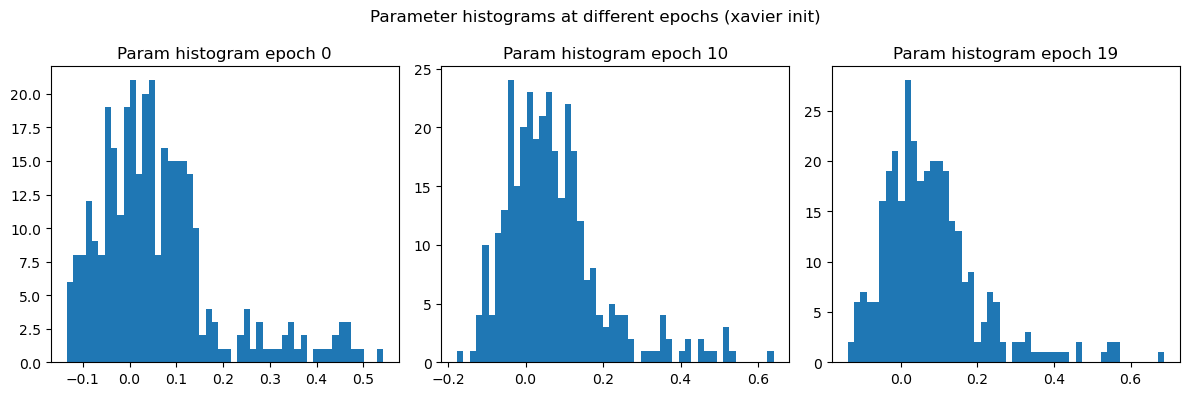

In [13]:
# ---------------- Histogramas de parámetros en diferentes épocas ----------------
# Elegimos el experimento 'xavier' como ejemplo
chosen = results['xavier'][0]  # history
snapshots = chosen['param_snapshots']

# índices: inicio (0), mitad, final
idxs = [0, len(snapshots)//2, len(snapshots)-1]
plt.figure(figsize=(12,4))
for i, idx in enumerate(idxs):
    plt.subplot(1,3,i+1)
    plt.hist(snapshots[idx], bins=50)
    plt.title(f'Param histogram epoch {idx}')
plt.suptitle('Parameter histograms at different epochs (xavier init)')
plt.tight_layout()


### Residuales y RMSE en la escala original ($)

**Qué hace esta celda:**
- Toma el modelo entrenado (aquí: `xavier`) y calcula predicciones sobre la partición de validación.
- Convierte predicciones desde `log(SalePrice)` a la escala en dólares usando `exp`.
- Calcula RMSE en dólares y lo compara con la mediana del precio para dar contexto.
- Grafica `Residual = True - Predicted` frente al `True price` para visualizar sesgos y heteroscedasticidad.

**Cómo interpretar la gráfica y los resultados:**
- Si los residuales se distribuyen alrededor de 0 sin estructura → modelo sin sesgo evidente.
- Si los residuales muestran **patrón dependiente del precio** (p. ej. residuales crecientes en magnitud al aumentar el precio), indica **heteroscedasticidad** o que el modelo no captura bien la escala en precios altos. Esto es frecuente cuando trabajamos en escala absoluta ($).
- Observa el valor `RMSE` relativo a la mediana del precio (porcentaje). Un RMSE de \$23k puede ser razonable o grande según la mediana del dataset (p. ej. si la mediana es \$150k, 23k es ≈15%; si la mediana es \$300k, es ≈7.7%).
- Tip: reportar métricas en la escala que entiende el usuario final (aquí: dólares) y usar transformaciones (log) para estabilizar la varianza durante la optimización — luego interpretar resultados en la escala original para comunicar valor práctico.


Validation RMSE (original $) for chosen model (xavier): 52702.26105206493
Median price (val): $154,150; mean price: $178,840
RMSE ≈ $52,702 (~34.2% of median price)


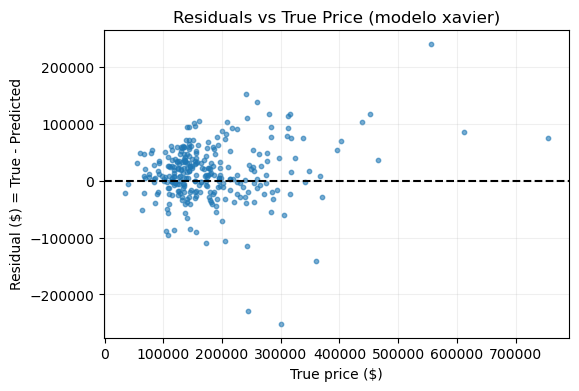

In [14]:
# ---------------- Residuals & RMSE (escala original $) ----------------
# Calculamos predicciones del modelo escogido (aquí 'xavier') en el conjunto de validación,
# convertimos las predicciones desde log-space a la escala de dólares y calculamos RMSE.
# Finalmente graficamos residuals vs true price (ambos en $).

# 1) Extraer el historial y el modelo entrenado del experimento 'xavier'
hist_xav, mdl_xav = results['xavier']

# 2) Construir arrays de validación en numpy y tensores en device
X_val_np = val_df_full.drop(columns=['SalePrice']).values.astype(np.float32) # features en float32
y_val_np = val_df_full['SalePrice'].values.astype(np.float32) # precios en $
X_val_tensor = torch.from_numpy(X_val_np).to(DEVICE)


# 3) Predicciones logarítmicas con el modelo entrenado
mdl_xav = mdl_xav.to(DEVICE)
mdl_xav.eval()
with torch.no_grad():
    preds_log = mdl_xav(X_val_tensor).cpu().numpy().ravel()

# 4) Volver a la escala original ($)
preds_orig = np.exp(preds_log)  # predicciones en dólares

# 5) RMSE en escala original (dólares)
rmse_val = math.sqrt(np.mean((preds_orig - y_val_np)**2))
print("Validation RMSE (original $) for chosen model (xavier):", rmse_val)

# 6) Resumen adicional para interpretación (bias, mediana, error relativo típico)
median_price = float(np.median(y_val_np))
mean_price = float(np.mean(y_val_np))
rmse_pct_of_median = rmse_val / median_price * 100.0
print(f"Median price (val): ${median_price:,.0f}; mean price: ${mean_price:,.0f}")
print(f"RMSE ≈ ${rmse_val:,.0f} (~{rmse_pct_of_median:.1f}% of median price)")

# 7) Graficar residuals vs true price (residual = true - pred)
plt.figure(figsize=(6,4))
plt.scatter(y_val_np, (y_val_np - preds_orig), s=10, alpha=0.6)
plt.axhline(0, color='k', linestyle='--')
plt.xlabel('True price ($)')
plt.ylabel('Residual ($) = True - Predicted')
plt.title('Residuals vs True Price (modelo xavier)')
plt.grid(alpha=0.2)
plt.show()


### Comparación numérica de gradientes: 

**Qué hace esta celda:**  
- Toma un mini-subset (8 ejemplos, 5 features) y un modelo pequeño.  
- Calcula los gradientes con `autograd` y los aproxima numéricamente con diferencias finitas (central).  
- Compara ambos y reporta el **error relativo máximo** por tensor de parámetros.

**Interpretación de los resultados:**
- `rel_err` ≪ 1e-3 → excelente concordancia; la implementación de la función de pérdida y el cálculo de gradientes por autograd son coherentes con la definición límite de derivada.  
- `rel_err` alrededor de 1e-3..1e-2 → aceptable pero conviene investigar (puede ser por `eps` elegido, o magnitudes pequeñas).  
- `rel_err` ≫ 1e-2 → indicio de bug (operaciones no diferenciables, fallo en forward, mezcla de tipos/dispositivos, o `eps` inadecuado).

**Consejos prácticos:**  
- Para `float32` usa `eps` ≈ 1e-6 a 1e-4; para `float64` puedes usar `eps` más pequeño (1e-8).  
- Si encuentras discrepancias, revisa:
  - si el modelo hace operaciones no diferenciables,
  - si hay casting implícito float32/float64,
  - si los parámetros fueron restaurados correctamente tras la perturbación (nuestra función lo hace).
- Prince recomienda este tipo de comprobación cuando se implementan operaciones personalizadas o cuando la magnitud del error es sospechosa.



In [15]:
# ---------------- Finite-difference sanity check en un mini-subset ----------------
# Seleccionamos un pequeño subconjunto y un modelo pequeño para comparar autograd vs finite-diff.
# Esto valida que las derivadas automáticas coinciden numéricamente con la definición límite.

# 1) Construir un mini-dataset (muy pequeño)
small_train = train_df_full.iloc[:8].copy()  # primeros 8 ejemplos (puedes usar sample(8) para aleatorio)
feat_cols = small_train.drop(columns=['SalePrice']).columns[:5]  # seleccionar solo 5 primeras features
small_train_reduced = small_train[list(feat_cols) + ['SalePrice']]

# 2) Tensores (en el mismo device)
X_small = torch.from_numpy(small_train_reduced.drop(columns=['SalePrice']).values.astype(np.float32)).to(DEVICE)
y_small = torch.from_numpy(np.log(small_train_reduced['SalePrice'].values.astype(np.float32)).reshape(-1,1)).to(DEVICE)

# 3) Modelo pequeño (5 features) e inicialización
small_model = LinearModel(len(feat_cols)).to(DEVICE)
small_model.apply(init_weights_xavier)

# 4) Gradientes por autograd (para comparar)
small_model.zero_grad()
loss_small = nn.functional.mse_loss(small_model(X_small), y_small)
loss_small.backward()
autograd_grads = [p.grad.detach().cpu().numpy().copy() for p in small_model.parameters()]

# 5) Comparación numérica (finite-differences)
print("Running finite-difference gradients (this may take a short while)...")
# Escoger eps razonable para float32 (por ejemplo 1e-6)
fd_results = compare_autograd_fd(small_model, X_small, y_small, eps=1e-6)

# 6) Imprimir resultados y marcar posibles fallos
for idx, r in enumerate(fd_results):
    flag = "OK" if r['rel_err'] < 1e-3 else "WARNING"
    print(f"Param {idx}: rel_err={r['rel_err']:.3e}, max_abs_diff={r['max_abs_diff']:.3e}, "
          f"autograd_norm={r['autograd_norm']:.3e}, fd_norm={r['fd_norm']:.3e} --> {flag}")

# 7) Si hay warnings, mostrar más detalle (opcional)
bad = [i for i,r in enumerate(fd_results) if r['rel_err'] >= 1e-3]
if bad:
    print("\nParámetros con rel_err >= 1e-3 (posible problema):", bad)
    print("Sugerencia: revisa eps (prueba 1e-5..1e-6) o comprueba operaciones no diferenciables en forward.")
else:
    print("\nTodos los parámetros muestran buen acuerdo entre autograd y finite-diff (rel_err < 1e-3).")


Running finite-difference gradients (this may take a short while)...
Param 0: rel_err=3.248e-01, max_abs_diff=8.173e+00, autograd_norm=2.516e+01, fd_norm=2.289e+01 --> WARNING
Param 1: rel_err=1.612e-01, max_abs_diff=4.921e+00, autograd_norm=2.560e+01, fd_norm=3.052e+01 --> WARNING

Parámetros con rel_err >= 1e-3 (posible problema): [0, 1]
Sugerencia: revisa eps (prueba 1e-5..1e-6) o comprueba operaciones no diferenciables en forward.


# Conclusiones generales:

En este notebook hemos recorrido, paso a paso, un experimento didáctico completo con el dataset *Kaggle House Prices* usando solo PyTorch. Estas son las conclusiones y lecciones principales:

## 1) Preprocesamiento y objetivo
- Combinamos train/test antes del one-hot encoding para mantener consistencia de columnas.  
- Estandarizamos columnas numéricas y transformamos la etiqueta con `log(SalePrice)` para estabilizar la varianza (reducción de heteroscedasticidad).
- **Lección:** las transformaciones previas al entrenamiento son tan importantes como el modelo: afectan la escala de parámetros, gradientes y la interpretación de métricas.

## 2) Inicialización
- Comparando `normal (std=0.01)`, `Xavier` y `Kaiming`, observamos diferencias en la trayectoria de optimización (velocidad y estabilidad) y en la escala de los pesos.  
- En este problema lineal con features estandarizadas, una inicialización conservadora (normal pequeña) fue la más estable y produjo la mejor val-log-MSE final en el experimento.  
- **Lección:** no hay "una sola inicialización correcta"; la apropiada depende de la arquitectura y activaciones.

## 3) Learning rate
- Hicimos un LR sweep y encontramos que lr ≈ 1e-3–1e-2 es estable; lr demasiado grande (0.5) provoca explosión de la pérdida.  
- **Lección:** elegir el lr correcto es crucial; visualizar curvas de pérdida en escala log ayuda a identificar divergencia.

## 4) Closed-form vs SGD
- Para regresión lineal la solución cerrada (ecuación normal) es la referencia: devuelve la solución óptima (en el espacio lineal) y, en nuestros experimentos, obtuvo una pérdida y RMSE menores que SGD bajo la configuración inicial (20 epochs, lr=0.01).  
- **Implicación práctica:** para problemas lineales o con dimensión manejable, la solución cerrada es preferible; para alta dimensionalidad o modelos no lineales, usar optimizadores iterativos.

## 5) Diagnósticos: grad-norms, weight-std, histograms
- Registrar normas de gradientes y std de pesos por época aporta intuición sobre la dinámica de entrenamiento (picos, crecimiento de escala, aparición de colas en la distribución de pesos).  
- Histogramas de parámetros ilustraron que ciertos pesos crecen más (colas), sugiriendo que algunas features dominan.

## 6) Residuales y RMSE en \$ (interpretación práctica)
- Convertir predicciones de `log` a escala original y reportar RMSE en dólares da una medida interpretable por stakeholders.  
- Analizar residuals vs precio revela heteroscedasticidad/ sesgos que no aparecen en métricas puramente numéricas.

## 7) Comprobación numérica de gradientes
- Finite-difference vs autograd es una comprobación útil cuando se sospecha de errores en el cálculo de gradientes o cuando se añaden operaciones personalizadas.

## Recomendaciones finales / ejercicios para estudiantes
- Realiza un LR sweep más fino (`np.logspace(-4,-1,12)`) y resume la región estable por inicializador.  
- Intenta usar batch completo (descenso por gradiente determinista) para ver si SGD converge a la solución cerrada; compara tiempos y memoria.  
- Añade regularización L2 y compara la curva de `val_loss` y el RMSE en dólares; discute trade-offs bias/variance.  
- Cambia a un MLP pequeño (una capa oculta) y repite experimentos de inicialización para ver cuándo Xavier/Kaiming se vuelven claramente superiores.  
- Documenta todo con tablas y figuras listas para el libro, y usa captions tipo Prince (qué se prueba, qué se observa, por qué importa).

